# Toàn cảnh Pipeline Xử lý ảnh Y khoa (End-to-End Demo)
**Mục tiêu:** Trình diễn trực quan toàn bộ vòng đời của bức ảnh: Từ lúc đầy nhiễu sáng/lông $\rightarrow$ Làm sạch $\rightarrow$ Bóc tách bằng Spatial K-Means + Snakes $\rightarrow$ Chấm điểm ABCD.

## 1. Import Thư viện & Load Ảnh

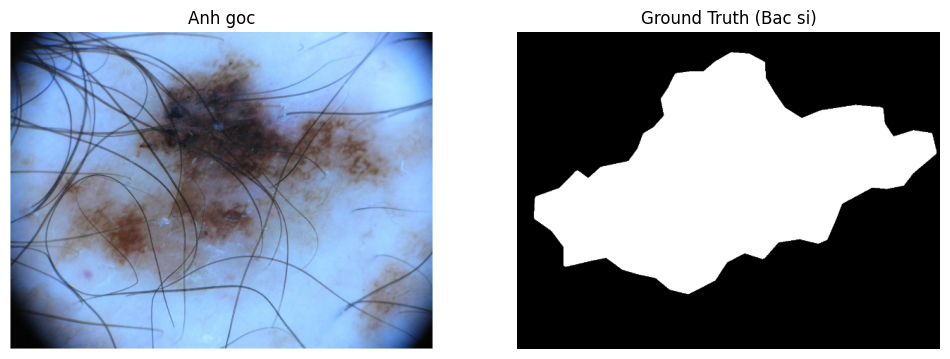

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Đảm bảo import được từ src
sys.path.append(r'd:\Computer Vision Final Project\Src code')

from src.preprocessing import apply_circular_mask, remove_hair, enhance_contrast_clahe, boost_faint_edges
from src.segmentation import get_kmeans_mask, get_snakes_mask
from src.features import evaluate_abcd_rule
from src.evaluation import calculate_iou

def show_images(imgs, titles):
    fig, axs = plt.subplots(1, len(imgs), figsize=(6 * len(imgs), 5))
    if len(imgs) == 1: axs = [axs]
    for ax, img, title in zip(axs, imgs, titles):
        if len(img.shape) == 3: ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        else: ax.imshow(img, cmap='gray')
        ax.set_title(title)
        ax.axis('off')
    plt.show()

img = cv2.imread(r'd:\Computer Vision Final Project\Src code\data\train\images\ISIC_0000074.jpg')
img = cv2.resize(img, (600, 450))
gt = cv2.imread(r'd:\Computer Vision Final Project\Src code\data\train\masks\ISIC_0000074_segmentation.png', 0)
gt = cv2.resize(gt, (600, 450))
show_images([img, gt], ['Anh goc', 'Ground Truth (Bac si)'])


## 2. Tiền xử lý: DullRazor (Xóa lông) & CLAHE (Cân bằng sáng)

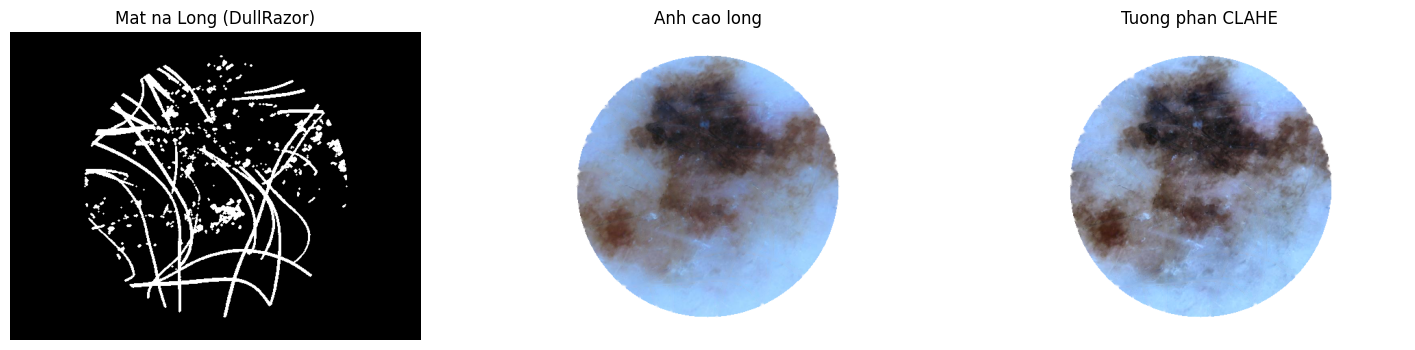

In [2]:
img_no_corners = apply_circular_mask(img, 0.85)
clean_img, hair_mask = remove_hair(img_no_corners, kernel_size=15, inpaint_rad=3)
clahe_color, clahe_gray = enhance_contrast_clahe(clean_img, 1.1)
smooth_l = cv2.GaussianBlur(boost_faint_edges(clahe_gray)[0], (5, 5), 0)
smooth_l = apply_circular_mask(smooth_l, 0.85)
clahe_color = apply_circular_mask(clahe_color, 0.85)

show_images([hair_mask, clean_img, clahe_color], ['Mat na Long (DullRazor)', 'Anh cao long', 'Tuong phan CLAHE'])


## 3. Phân đoạn K-Means (Bắt viền nhạt bằng Spatial Prior)

Sử dụng K-Means lấy 2 cụm màu gần tâm ảnh nhất để không bỏ sót vùng viền nhạt...


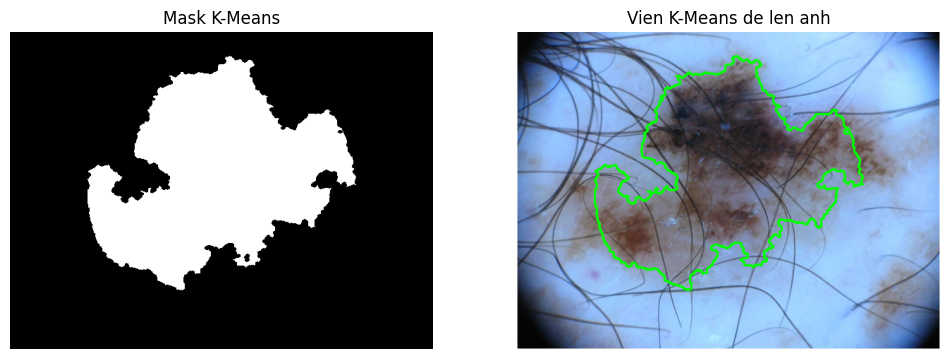

IoU K-Means: 67.46%


In [3]:
print("Sử dụng K-Means lấy 2 cụm màu gần tâm ảnh nhất để không bỏ sót vùng viền nhạt...")
kmeans_mask = get_kmeans_mask(clahe_color, k=4)
res_kmeans = img.copy()
contours, _ = cv2.findContours(kmeans_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cv2.drawContours(res_kmeans, contours, -1, (0, 255, 0), 2)

show_images([kmeans_mask, res_kmeans], ['Mask K-Means', 'Vien K-Means de len anh'])
print(f"IoU K-Means: {calculate_iou(kmeans_mask, gt)*100:.2f}%")


## 4. Rắn bò Morphological Snakes (Chan-Vese)

Dây thun Snakes bò 35 vòng từ mốc K-Means để ôm khít rãnh khối u...


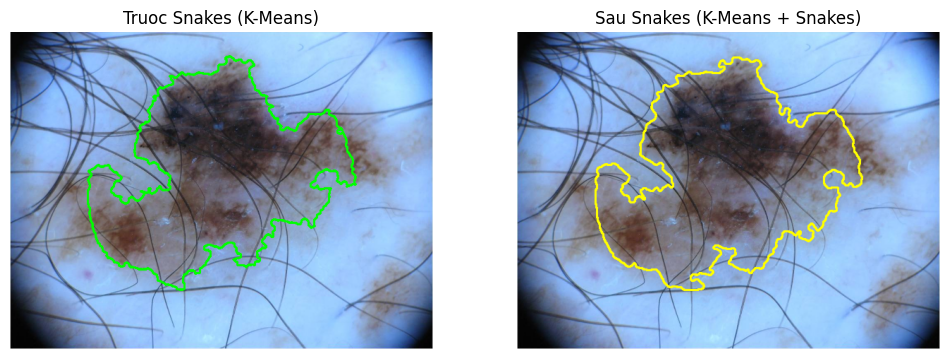

IoU Snakes: 71.09%


In [4]:
print("Dây thun Snakes bò 35 vòng từ mốc K-Means để ôm khít rãnh khối u...")
snakes_mask = get_snakes_mask(smooth_l, kmeans_mask, num_iter=35)
res_snakes = img.copy()
contours, _ = cv2.findContours(snakes_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cv2.drawContours(res_snakes, contours, -1, (0, 255, 255), 2)

show_images([res_kmeans, res_snakes], ['Truoc Snakes (K-Means)', 'Sau Snakes (K-Means + Snakes)'])
print(f"IoU Snakes: {calculate_iou(snakes_mask, gt)*100:.2f}%")


## 5. Đánh giá Y khoa (ABCD Rule)

In [5]:
result = evaluate_abcd_rule(img, snakes_mask, snakes_mask)
print("="*50)
print("ĐÁNH GIÁ ĐẶC TRƯNG ABCD LÂM SÀNG:")
print(f" - [A] Asymmetry (Bất đối xứng) : {result['A']} điểm")
print(f" - [B] Border (Nham nhở)        : {result['B']} điểm")
print(f" - [C] Color (Đa sắc)           : {result['C']} điểm")
print(f" - [D] Diameter (Đường kính)    : {result['D_score']} điểm ({result['D_mm']} mm)")
print("-"*50)
print(f"=> TOTAL DERMOSCOPY SCORE (TDS): {result['TDS']}")
print(f"=> CHẨN ĐOÁN (DIAGNOSIS)       : {result['Diagnosis'].upper()}")
print("="*50)


ĐÁNH GIÁ ĐẶC TRƯNG ABCD LÂM SÀNG:
 - [A] Asymmetry (Bất đối xứng) : 2 điểm
 - [B] Border (Nham nhở)        : 8 điểm
 - [C] Color (Đa sắc)           : 3 điểm
 - [D] Diameter (Đường kính)    : 5.0 điểm (7.64 mm)
--------------------------------------------------
=> TOTAL DERMOSCOPY SCORE (TDS): 7.4
=> CHẨN ĐOÁN (DIAGNOSIS)       : MALIGNANT MELANOMA
